# Example: Train a diffusion model for image generation

This example guides you through developing and training a simple [diffusion model](https://en.wikipedia.org/wiki/Diffusion_model) using a [U-Net architecture](https://en.wikipedia.org/wiki/U-Net) for image generation using Flax NNX.

In this tutorial, you'll learn how to:

- Load and preprocess the dataset
- Define the U-Net model from [Dhariwal & Nichol '21](https://proceedings.neurips.cc/paper_files/paper/2021/file/49ad23d1ec9fa4bd8d77d02681df5cfa-Paper.pdf) with NNX
- Create the loss and training functions for the flow matching diffusion objective simultaniously proposed by [Lipman et al 23](https://arxiv.org/pdf/2210.02747) and [Liu et al '22](https://arxiv.org/pdf/2209.03003)
- Visualize and track the model’s progress

Start with importing JAX, JAX NumPy, Flax NNX, Optax, matplotlib and scikit-learn.

In [7]:
from sklearn.datasets import load_digits
import jax
import optax
from flax import nnx
import jax.numpy as jnp
from functools import partial
import matplotlib.pyplot as plt

## Loading and preprocessing the data

We'll use the small, self-contained [scikit-learn `digits` dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) for ease of experimentation to demonstrate diffusion model training. For simplicity, we'll focus on generating only the digit '2' (two).

This involves several steps, such as:

1. Loading the dataset
2. Filtering the images of '2' (two)
3. Normalizing pixel values to `[-1, 1]` to match the Gaussian noise distribution
4. Converting the data into `jax.Array`s
5. Reshaping the data

In [8]:
digits = load_digits()
# Filter for digit '2' (two) images.
images = digits.images[digits.target == 2]
# Normalize pixel values into floating-point arrays in the `[-1, 1]` interval.
images = images / 16.0 * 2 - 1
# Convert to `jax.Array`s.
images = jnp.asarray(images)
# Reshape to `(num_images, height, width, channels)` for convolutional layers.
images = images.reshape(-1, 8, 8, 1)
data_shape = images.shape[1:]

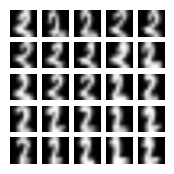

In [9]:
# Visualize sample images.
fig, axes = plt.subplots(5, 5, figsize=(2, 2))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i, ..., 0], cmap='gray', interpolation='gaussian')
        ax.axis('off')
plt.show()

## Building the U-Net

In this example, we'll use a specific diffusion variant known as *flow matching*. A flow matching diffusion model is a neural network representing a velocity field that can transform Gaussian noise into a space of images. To get an image, we'll sample a starting value $x_0 \sim \mathcal{N}(0, 1)$, and then propagate it according the differential equation $\frac{dx}{dt} = f_\theta(x,t)$ where $f_\theta(x,t)$ applies the neural network with parameters $\theta$. We'll integrate the differential equation from $t=0$ starting at state $x_0$ up to $t=1$, producing image $x_1$.

Our neural network will use a [U-Net architecture](https://en.wikipedia.org/wiki/U-Net) which consists of the following:

- An [encoder](https://en.wikipedia.org/wiki/Autoencoder) path that [downsamples](https://en.wikipedia.org/wiki/Downsampling_(signal_processing)) the input image, extracting features.
- A bridge with a (self-)[attention mechanism](https://en.wikipedia.org/wiki/Attention_(machine_learning) that connects the encoder with the decoder.
- A [decoder](https://en.wikipedia.org/wiki/Autoencoder) path that [upsamples](https://en.wikipedia.org/wiki/Upsampling) the feature representations learned by the encoder, reconstructing the output image.
- [Skip connections](https://en.wikipedia.org/wiki/Residual_neural_network#Residual_connection) between the encoder and the decoder.

Let's define a class called `UNet` by subclassing [`flax.nnx.Module`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/module.html#flax.nnx.Module) and using, among other things, [`flax.nnx.Linear`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/linear.html#flax.nnx.Linear) (linear or dense layers for time embedding and time projection layers), [`flax.nnx.LayerNorm`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/normalization.html#flax.nnx.LayerNorm) (layer normalization), [`flax.nnx.MultiHeadAttention`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/attention.html#flax.nnx.MultiHeadAttention) (attention) and [`flax.nnx.Conv`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/linear.html#flax.nnx.Conv) (convolution layers for the output layer).

In [10]:
class UNet(nnx.Module):
    def __init__(self,
                 in_channels: int,
                 out_channels: int,
                 features: int,
                 time_emb_dim: int = 128,
                 *,
                 rngs: nnx.Rngs):
        """
        Initialize the U-Net architecture with time embedding.
        """
        self.features = features

        # Time embedding layers for diffusion timestep conditioning.
        self.time_mlp = nnx.Sequential(
            nnx.Linear(in_features=time_emb_dim, out_features=time_emb_dim, rngs=rngs),
            nnx.gelu,
            nnx.Linear(in_features=time_emb_dim, out_features=time_emb_dim, rngs=rngs))

        # Time projection layers for different scales.
        self.time_proj = nnx.List([
            nnx.Linear(in_features=time_emb_dim, out_features=features, rngs=rngs),
            nnx.Linear(in_features=time_emb_dim, out_features=features * 2, rngs=rngs),
            nnx.Linear(in_features=time_emb_dim, out_features=features * 4, rngs=rngs),
            nnx.Linear(in_features=time_emb_dim, out_features=features * 8, rngs=rngs)])

        # The encoder path.
        self.down_convs = nnx.List([
            ResBlock(in_channels, features, rngs),
            ResBlock(features, features * 2, rngs),
            ResBlock(features * 2, features * 4, rngs),
            ResBlock(features * 4, features * 8, rngs),
        ])

        # Multi-head self-attention blocks.
        self.attention1 = nnx.MultiHeadAttention(num_heads=1, in_features=features * 4, decode=False, rngs=rngs)
        self.attention2 = nnx.MultiHeadAttention(num_heads=1, in_features=features * 8, decode=False, rngs=rngs)

        # The bridge connecting the encoder and the decoder.
        self.bridge_down = ResBlock(features * 8, features * 16, rngs)
        self.bridge_attention = nnx.MultiHeadAttention(num_heads=1, in_features=features * 16, decode=False, rngs=rngs)
        self.bridge_up = ResBlock(features * 16, features * 16, rngs)

        # Decoder path with skip connections.
        self.up_convs = nnx.List([
            ResBlock(features * 24, features * 8, rngs),
            ResBlock(features * 12, features * 4, rngs),
            ResBlock(features * 6, features * 2, rngs),
            ResBlock(features * 3, features, rngs),
        ])

        # Output layers.
        self.final_norm = nnx.LayerNorm(features, rngs=rngs)
        self.final_conv = nnx.Conv(in_features=features,
                                 out_features=out_channels,
                                 kernel_size=(3, 3),
                                 strides=(1, 1),
                                 padding=((1, 1), (1, 1)),
                                 rngs=rngs)

    def _apply_attention(self, attn: nnx.MultiHeadAttention, x: jax.Array) -> jax.Array:
        B, H, W, C = x.shape
        # Flatten spatial dimensions, apply attention, then restore the spatial shape.
        out = attn(x.reshape(B, H * W, C)).reshape(B, H, W, C)
        return x + out  # A ResNet-style residual connection.

    def _pos_encoding(self, t: jax.Array, dim: int) -> jax.Array:
        """Applies sinusoidal positional encoding for time embedding.

        Args:
            t (jax.Array): The time embedding, representing the timestep.
            dim (int): The dimension of the output positional encoding.

        Returns:
            jax.Array: The sinusoidal positional embedding per timestep.

        """
        # Calculate half the embedding dimension.
        half_dim = dim // 2
        # Compute the logarithmic scaling factor for sinusoidal frequencies.
        emb = jnp.log(10000.0) / (half_dim - 1)
        # Generate a range of sinusoidal frequencies.
        emb = jnp.exp(jnp.arange(half_dim) * -emb)
        # Create the positional encoding by multiplying time embeddings with.
        emb = (1000 * t[:, None]) * emb[None, :]

        # Concatenate sine and cosine components for richer representation.
        emb = jnp.concatenate([jnp.sin(emb), jnp.cos(emb)], axis=1)
        return emb

    def _downsample(self, x: jax.Array) -> jax.Array:
        """Downsamples the input feature map with max pooling."""
        return nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2), padding='SAME')

    def _upsample(self, x: jax.Array, target_size: int) -> jax.Array:
        """Upsamples the input feature map using nearest neighbor interpolation."""
        return jax.image.resize(x,
                              (x.shape[0], target_size, target_size, x.shape[3]),
                              method='nearest')

    def __call__(self, x: jax.Array, t: jax.Array) -> jax.Array:
        """Perform the forward pass through the U-Net using time embeddings."""

        # Time embedding and projection.
        t_emb = self.time_mlp(self._pos_encoding(t, 128)) # Sinusoidal positional encoding for time.

        # The encoder path with time injection.
        t_embs = [proj(t_emb)[:, None, None, :] for proj in self.time_proj]
        attns = [None, None, self.attention1, self.attention2]

        ds = []
        for conv, t_e, attn in zip(self.down_convs, t_embs, attns):
            inp = self._downsample(ds[-1]) if ds else x
            d = conv(inp)
            if attn is not None:
                d = self._apply_attention(attn, d)  # Apply self-attention.
            d = d + jnp.broadcast_to(t_e, d.shape)  # Add the time embedding to the feature map.
            ds.append(d)

        # The bridge.
        b = self._downsample(ds[-1])
        b = self.bridge_down(b)
        b = self._apply_attention(self.bridge_attention, b)
        b = self.bridge_up(b)

        # The decoder path with skip connections.
        u = b
        for conv, skip in zip(self.up_convs, reversed(ds)):
            u = conv(jnp.concatenate([self._upsample(u, skip.shape[1]), skip], axis=-1))

        # Final layers.
        x = self.final_norm(u)
        x = nnx.gelu(x)
        return self.final_conv(x)

Each block in our UNet will use residual connections. We can abstract this pattern into a second `nnx.Module` subclass.

In [11]:
class ResBlock(nnx.Module):
    def __init__(self, in_channels: int, out_channels: int, rngs: nnx.Rngs):
        # Convolutional layers with layer normalization.
        self.conv1 = nnx.Conv(in_features=in_channels,
                        out_features=out_channels,
                        kernel_size=(3, 3),
                        strides=(1, 1),
                        padding=((1, 1), (1, 1)),
                        rngs=rngs)
        self.norm1 = nnx.LayerNorm(out_channels, rngs=rngs)
        self.conv2 = nnx.Conv(in_features=out_channels,
                        out_features=out_channels,
                        kernel_size=(3, 3),
                        strides=(1, 1),
                        padding=((1, 1), (1, 1)),
                        rngs=rngs)
        self.norm2 = nnx.LayerNorm(out_channels, rngs=rngs)

        # Projection shortcut if dimensions change.
        self.shortcut = nnx.Conv(in_features=in_channels,
                            out_features=out_channels,
                            kernel_size=(1, 1),
                            strides=(1, 1),
                            rngs=rngs)
    def __call__(self, x):
        identity = self.shortcut(x)
        x = nnx.gelu(self.norm1(self.conv1(x)))
        x = nnx.gelu(self.norm2(self.conv2(x)))
        return x + identity

Finally, we can instantiate our model.

In [12]:
rngs=nnx.Rngs(0)
model = UNet(1, 1, 64, rngs=rngs)

## Training the Model

To train our U-Net, we'll use the *Conditional Flow Matching* loss. Let $p_t(x | x_1) = \mathcal{N}(tx_1, (1 - t)^2I)$ so that $p_0(x | x_1)$ is standard Gaussian noise and $p_1(x | x_1)$ is a delta distribution around $x_1$. Let $u(x,t | x_1)$ be a velocity field which, when integrated up to time $t$ starting from Gaussian noise, produces samples from $p_t(x | x_1)$. Let $q(x_1)$ be the image distribution we want to generate samples from. The *Conditional Flow Matching* loss is given by

$$
L(\theta) = E_{t, p_t(x | x_1), q(x_1)}\| u(x, t | x_1) - f_\theta(x, t)\|^2
$$

As shown in Lipman '23, a velocity field $f_\theta$ that minimizes the Conditional Flow Matching loss will transform our Gaussian noise into image samples, just like we want! To find the velocity field $u(x,t | x_1)$, we can just use $\frac{dx}{dt} = \frac{x_1 - x}{1 - t}$: a little calculus shows that it integrates as desired. As $x_t = tx_1 - x_0$, $\frac{x_1 - x_t}{1 - t}$ simplifies to $x_1 - x_0$.

The loss is an expectation over $t \in [0, 1]$, and the choice of how to sample $t$ affects training quality. Uniform sampling spends equal budget on easy near-$t=0$ (pure noise) and near-$t=1$ (near-clean) steps, but the velocity field is hardest to learn in the middle of the trajectory where noise and signal overlap most. Following SD3 and Flux, we use *logit-normal* time sampling: draw $u \sim \mathcal{N}(0, 1)$ and set $t = \sigma(u)$ where $\sigma$ is the logistic function. Because $\sigma$ maps the bulk of a standard normal to the middle of $[0, 1]$, this concentrates training on the challenging mid-trajectory region.

In [13]:
num_epochs = 2000
batch_size = 64
learning_rate = 5e-4

In [14]:
# Learning rate schedule configuration.
# Start with the warmup, then cosine decay.
warmup_steps = 1000 # Number of steps.
total_steps = num_epochs # Total number of training steps.

# Multiple schedules using `optax.join_schedules`:
# Linear transition (`optax.linear_schedule`) (for the warmup) and
# and cosine learning rate decay (`optax.cosine_decay_schedule`).
schedule_fn = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0,
            end_value=learning_rate,
            transition_steps=warmup_steps
        ),
        optax.cosine_decay_schedule(
            init_value=learning_rate,
            decay_steps=total_steps - warmup_steps,
            alpha=0.01
        )
    ],
    boundaries=[warmup_steps] # Where the schedule transitions from the warmup to cosine decay.
)

# Optimizer configuration (AdamW) with gradient clipping.
optimizer = nnx.ModelAndOptimizer(model, optax.chain(
    optax.clip_by_global_norm(0.5), # Gradient clipping.
    optax.adamw(
        learning_rate=schedule_fn,
        weight_decay=2e-5,
        b1=0.9,
        b2=0.999,
        eps=1e-8
    )
))

In [15]:
def loss_fn(model, x1, rngs):
    batch_size = x1.shape[0]
    u = rngs.normal((batch_size,))
    t = jax.nn.sigmoid(u)  # Logit-normal time sampling (SD3/Flux).
    t_full = t[:,None,None,None]
    x0 = rngs.normal(x1.shape)
    xt = (1 - t_full) * x0 + t_full * x1
    return jnp.mean((model(xt, t) - (x1 - x0))**2)

In [16]:
@nnx.jit
def train_step(model, data, rngs, optimizer):
    loss, grads = nnx.value_and_grad(loss_fn)(model, data, rngs)
    optimizer.update(grads)
    return loss

## Visualizing Samples

While training, we'll want to periodically visualize the image samples our diffusion model generates. To do this, we'll use the `diffrax` library for numerical integration.

In [17]:
import diffrax as dfx

In [18]:
sample_size=5

In [19]:
@nnx.jit
def sample(model, rngs):
    x0 = rngs.normal((sample_size**2, *data_shape))
    def drift(t, y, args):
        return model(y[None], t * jnp.ones(1))[0]
    term = dfx.ODETerm(drift)
    solver = dfx.Tsit5()
    def forward(x):
        return dfx.diffeqsolve(term, solver, 0, 1, 0.1, x).ys[0]
    return jax.vmap(forward)(x0)

In [20]:
def draw_imgs(samples):
    fig, axes = plt.subplots(5, 5, figsize=(2, 2))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, ..., 0], cmap='gray', interpolation='gaussian')
        ax.axis('off')
    plt.show()

In [21]:
def draw_sample(rngs):
    draw_imgs(jnp.clip(sample(model, rngs), -1, 1))

## Running the Training Loop

Epoch 0, Loss: 1.8359


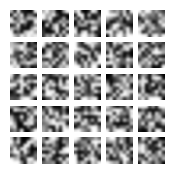

Epoch 100, Loss: 0.8380
Epoch 200, Loss: 0.4750
Epoch 300, Loss: 0.3905
Epoch 400, Loss: 0.3597
Epoch 500, Loss: 0.3436


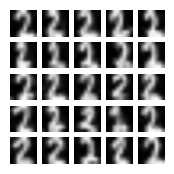

Epoch 600, Loss: 0.3038
Epoch 700, Loss: 0.3109
Epoch 800, Loss: 0.3199
Epoch 900, Loss: 0.3033
Epoch 1000, Loss: 0.3023


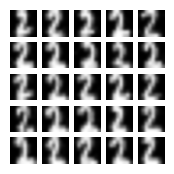

Epoch 1100, Loss: 0.2952
Epoch 1200, Loss: 0.2614
Epoch 1300, Loss: 0.2502
Epoch 1400, Loss: 0.2623
Epoch 1500, Loss: 0.2526


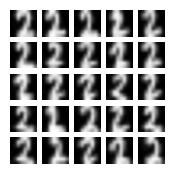

Epoch 1600, Loss: 0.2445
Epoch 1700, Loss: 0.2445
Epoch 1800, Loss: 0.2301
Epoch 1900, Loss: 0.2102
Epoch 2000, Loss: 0.2119


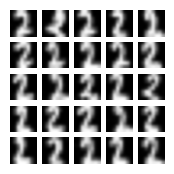

In [22]:
losses = []
for epoch in range(num_epochs + 1):
    loss = train_step(model, images, rngs, optimizer)
    losses.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
    if epoch % 500 == 0:
        draw_sample(rngs)

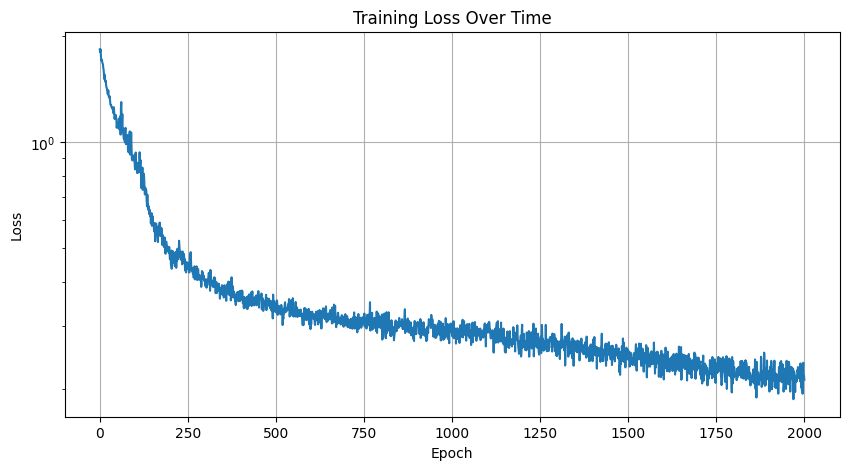

In [26]:
# Plot the training loss history with logarithmic scaling.
plt.figure(figsize=(10, 5))            # Create figure with wide aspect ratio for clarity
plt.plot(losses)                       # losses: List[float] - historical loss values.
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')                      # Use the log scale to better visualize exponential decay.
plt.grid(True)                         # Add a grid for easier value reading.
plt.show()

## Visualizing Reconstructions

A well-trained flow matching model defines an invertible map between noise and images: integrating the learned velocity field forward takes noise to images, and integrating it *backward* (negating the field, running time from 1 to 0) takes images back to noise. We can use this to sanity-check the model — encoding real images to noise and decoding back should recover the originals faithfully. If this check fails, it would mean that our learned velocity field wasn't smooth enough for numerical integration to work properly.

In [50]:
@nnx.jit
def encode_decode(imgs):
    """Encode images to noise (t: 1→0), then decode back (t: 0→1)."""
    def drift(t, y, args):
        return model(y[None], t * jnp.ones(1))[0]
    term = dfx.ODETerm(drift)
    solver = dfx.Tsit5()

    def encode(x1):
        # Integrate backwards: negate the velocity field to reverse the flow.
        return dfx.diffeqsolve(term, solver, t0=1, t1=0, dt0=-0.1, y0=x1,
                               saveat=dfx.SaveAt(ts=jnp.linspace(1,0,4))).ys

    def decode(x0):
        return dfx.diffeqsolve(term, solver, t0=0, t1=1, dt0=0.1, y0=x0,
                               saveat=dfx.SaveAt(ts=jnp.linspace(0,1,4))).ys

    noise = jax.vmap(encode)(imgs)
    recons = jax.vmap(decode)(noise[:, -1])
    return jnp.clip(jnp.concatenate([noise[:, :-1], recons], axis=1), -1, 1)

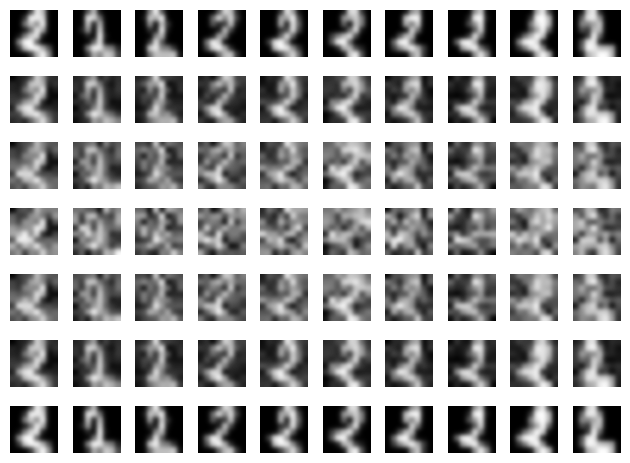

In [54]:
originals = images[:10]
progression = encode_decode(originals)
fig, axes = plt.subplots(7, 10)
for i in range(7):
    for j in range(10):
        axes[i,j].imshow(progression[j, i, ..., 0], cmap='gray', interpolation='gaussian')
        axes[i,j].axis('off')
plt.tight_layout()
plt.show()

As we hoped, encoding and decoding an image brings us back to the same place. The middle row supposedly representing Gaussian noise samples doesn't look exactly Gaussian: you can still make out the '2' lying in the background. This is a known property of flow matching diffusion models: the latent codes are just noisy versions of the original images.

## Summary
In this tutorial, we implemented a simple diffusion model using JAX and Flax NNX, and trained it with Optax. The model consisted of the U-Net model architecture with attention mechanisms, and trained it the *conditional flow matching* loss. At this point, you'd normally try training with a larger dataset.